# Отчет по лабораторной работе 2

In [1]:
install.packages("ggplot2")
install.packages("dplyr")
install.packages("fitdistrplus")

library(ggplot2)
library(dplyr)
library(fitdistrplus)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


Loading required package: survival



## 1. Идентификация распределений

### Задание 6

**Формулировка**  
Имеются две независимые выборки времен наработки на отказ однотипных устройств, но работающих в разных условиях (нормальные и тяжелые условия):

Выборка A (нормальные условия):

145, 234, 67, 312, 189, 256, 98, 178, 345, 123,  
287, 156, 201, 89, 267, 134, 298, 176, 215, 92

Выборка B (тяжелые условия):

56, 123, 45, 89, 67, 112, 34, 78, 95, 43,  
132, 76, 54, 101, 82, 63, 117, 48, 71, 88

Выдвинуть гипотезу $H_0$: $\\lambda_A = \\lambda_B$ (интенсивности отказов равны) против альтернативы $H_1$: $\\lambda_A < \\lambda_B$ (в тяжелых условиях интенсивность выше). Проверить гипотезу на уровнях значимости $\\alpha = 0.05$ и $\\alpha = 0.01$.  
Проверить гипотезу о соответствии выборок экспоненциальному закону распределения, для распределения, отличного от экспоненциального, подобрать подходящее распределение Эрланга.

In [2]:
A <- c(
  145, 234, 67, 312, 189, 256, 98, 178, 345, 123,
  287, 156, 201, 89, 267, 134, 298, 176, 215, 92
)

B <- c(
  56, 123, 45, 89, 67, 112, 34, 78, 95, 43,
  132, 76, 54, 101, 82, 63, 117, 48, 71, 88
)

nA <- length(A)
nB <- length(B)

meanA <- mean(A)
meanB <- mean(B)
lambdaA_hat <- 1 / meanA
lambdaB_hat <- 1 / meanB

cat("Выборка A: среднее =", meanA, "интенсивность λ_A^ =", lambdaA_hat, "\n")
cat("Выборка B: среднее =", meanB, "интенсивность λ_B^ =", lambdaB_hat, "\n\n")

# Проверка экспоненциальности каждой выборки (Колмогоров–Смирнов)
ks_A <- ks.test(A, "pexp", rate = lambdaA_hat)
ks_B <- ks.test(B, "pexp", rate = lambdaB_hat)

cat("KS-тест для выборки A (Exp(λ_A^)):\n")
print(ks_A)
cat("\nKS-тест для выборки B (Exp(λ_B^)):\n")
print(ks_B)

# Проверка гипотезы H0: λ_A = λ_B  <=>  M[A] = M[B]
# Альтернатива: λ_A < λ_B  <=>  M[A] > M[B]
# Поэтому используем односторонний t-тест с альтернативой mean(A) > mean(B)

t_res <- t.test(A, B, alternative = "greater")
cat("\nОдносторонний t-тест (H1: mean(A) > mean(B)):\n")
print(t_res)

alpha1 <- 0.05
alpha2 <- 0.01

cat("\nСравнение p-value с уровнями значимости:\n")
cat("p-value =", t_res$p.value, "\n")
cat("При α =", alpha1, ifelse(t_res$p.value < alpha1,
                              "отвергаем H0 (интенсивности различаются)",
                              "нет оснований отвергнуть H0"), "\n")
cat("При α =", alpha2, ifelse(t_res$p.value < alpha2,
                              "отвергаем H0 (интенсивности различаются)",
                              "нет оснований отвергнуть H0"), "\n\n")

# Если экспоненциальная модель плохо согласуется, можно подобрать распределение Эрланга
# Оценки параметров Эрланга по моментам: k ≈ (E[T]^2 / Var[T]), λ ≈ E[T] / Var[T]

erlang_params <- function(x) {
  m <- mean(x)
  v <- var(x)
  k_hat <- m^2 / v
  k_int <- round(k_hat)
  lambda_hat <- m / v
  list(k_hat = k_hat, k_int = k_int, lambda_hat = lambda_hat)
}

ep_A <- erlang_params(A)
ep_B <- erlang_params(B)

cat("Параметры Эрланга по моментам для выборки A:\n")
print(ep_A)
cat("\nПараметры Эрланга по моментам для выборки B:\n")
print(ep_B)


Выборка A: среднее = 193.1 интенсивность λ_A^ = 0.005178664 
Выборка B: среднее = 78.7 интенсивность λ_B^ = 0.01270648 

KS-тест для выборки A (Exp(λ_A^)):

	Exact one-sample Kolmogorov-Smirnov test

data:  A
D = 0.31928, p-value = 0.02592
alternative hypothesis: two-sided


KS-тест для выборки B (Exp(λ_B^)):

	Exact one-sample Kolmogorov-Smirnov test

data:  B
D = 0.37096, p-value = 0.005608
alternative hypothesis: two-sided


Односторонний t-тест (H1: mean(A) > mean(B)):

	Welch Two Sample t-test

data:  A and B
t = 5.9061, df = 23.494, p-value = 2.336e-06
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 81.23166      Inf
sample estimates:
mean of x mean of y 
    193.1      78.7 


Сравнение p-value с уровнями значимости:
p-value = 2.336097e-06 
При α = 0.05 отвергаем H0 (интенсивности различаются) 
При α = 0.01 отвергаем H0 (интенсивности различаются) 

Параметры Эрланга по моментам для выборки A:
$k_hat
[1] 5.565236

$k_int
[1] 6


## 2. Нахождение плотности распределения суммы независимых случайных величин

### Задача 5

**Формулировка**  
В систему поступают два независимых пуассоновских потока заявок: $X_1 \\sim Pois(5)$ и $X_2 \\sim Pois(3)$. Система может обработать не более 10 заявок в единицу времени. Если сумма $S = X_1 + X_2$ превышает 10, то "лишние" заявки теряются.

Найти распределение числа обработанных заявок $Y = \\min(S, 10)$.  
Вычислить $M[Y]$, $D[Y]$ и вероятность потери заявки $P(S > 10)$.  
Найти условное математическое ожидание $M[S | S > 10]$. Построить имитационную модель процесса и сравнить теоретические результаты с выборочными характеристиками.

k,P_Y
<int>,<dbl>
0,0.0003354626
1,0.0026837010
2,0.0107348041
3,0.0286261442
4,0.0572522885
5,0.0916036616
6,0.1221382155
7,0.1395865320
8,0.1395865320


Теоретическое M[Y]: 7.574136 
Теоретическая D[Y]: 4.699906 
Вероятность потери заявки P(S > 10): 0.1841142 
Условное M[S | S > 10] (теоретически): 12.31304 

Выборочное M[Y]: 7.57334 
Выборочная D[Y]: 4.663788 
Оценка P(S > 10) по моделированию: 0.18325 
Оценка M[S | S > 10] по моделированию: 12.3069 


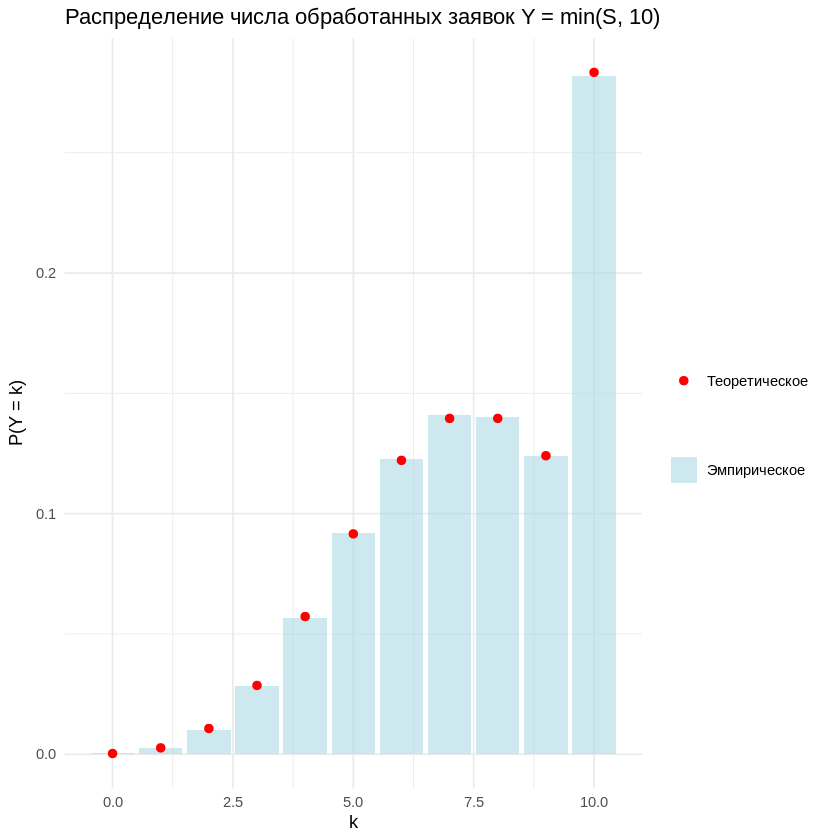

In [3]:
lambda1 <- 5   # для X1
lambda2 <- 3   # для X2
lambdaS <- lambda1 + lambda2

# S ~ Pois(lambdaS)
k <- 0:10
pS_k <- dpois(k, lambdaS)

# Распределение Y = min(S, 10)
pY <- pS_k
p_tail <- 1 - ppois(10, lambdaS)
pY[11] <- pY[11] + p_tail

data.frame(k = 0:10, P_Y = pY)

# Теоретические M[Y], D[Y]
EY <- sum((0:10) * pY)
EY2 <- sum((0:10)^2 * pY)
DY <- EY2 - EY^2

cat("Теоретическое M[Y]:", EY, "\n")
cat("Теоретическая D[Y]:", DY, "\n")

# Вероятность потери заявки P(S > 10)
P_loss <- 1 - ppois(10, lambdaS)
cat("Вероятность потери заявки P(S > 10):", P_loss, "\n")

# Условное математическое ожидание M[S | S > 10]
k_tail <- 11:60
p_tail_k <- dpois(k_tail, lambdaS)
M_S_cond <- sum(k_tail * p_tail_k) / sum(p_tail_k)
cat("Условное M[S | S > 10] (теоретически):", M_S_cond, "\n\n")

# Имитационная модель
set.seed(2026 + 10 + 5)
N <- 100000
X1 <- rpois(N, lambda1)
X2 <- rpois(N, lambda2)
S <- X1 + X2
Y <- pmin(S, 10)

cat("Выборочное M[Y]:", mean(Y), "\n")
cat("Выборочная D[Y]:", var(Y), "\n")
cat("Оценка P(S > 10) по моделированию:", mean(S > 10), "\n")
cat("Оценка M[S | S > 10] по моделированию:", mean(S[S > 10]), "\n")

# Сравнение теоретического и эмпирического распределения Y
df_Y_theor <- data.frame(k = 0:10, P = pY)
tab_emp <- table(factor(Y, levels = 0:10)) / N
df_Y_emp <- data.frame(k = 0:10, P = as.numeric(tab_emp))

ggplot() +
  geom_col(data = df_Y_emp, aes(x = k, y = P, fill = "Эмпирическое"), alpha = 0.6) +
  geom_point(data = df_Y_theor, aes(x = k, y = P, colour = "Теоретическое"), size = 2) +
  labs(title = "Распределение числа обработанных заявок Y = min(S, 10)",
       x = "k", y = "P(Y = k)") +
  scale_fill_manual(values = c("Эмпирическое" = "lightblue"), name = "") +
  scale_colour_manual(values = c("Теоретическое" = "red"), name = "") +
  theme_minimal()

In [4]:
head(Y)
head(S)

print("Теоретические P(Y=k):")
print(pY)
print("Эмпирические P(Y=k):")
print(as.numeric(table(factor(Y, levels = 0:10)) / N))

cat("Теоретическое E[Y]:", EY, "\n")
cat("Эмпирическое mean(Y):", mean(Y), "\n")

[1]  6 10  9  6 10  6

[1]  6 11  9  6 10  6

[1] "Теоретические P(Y=k):"
 [1] 0.0003354626 0.0026837010 0.0107348041 0.0286261442 0.0572522885
 [6] 0.0916036616 0.1221382155 0.1395865320 0.1395865320 0.1240769173
[11] 0.2833757413
[1] "Эмпирические P(Y=k):"
 [1] 0.00040 0.00268 0.01014 0.02819 0.05665 0.09217 0.12288 0.14116 0.14028
[10] 0.12378 0.28167
Теоретическое E[Y]: 7.574136 
Эмпирическое mean(Y): 7.57334 


## 3. Дискретные, непрерывные случайные величины и их характеристики

### Задание 4

**Формулировка**  
В колл-центр поступают три независимых потока вызовов: $X_1$ (техподдержка), $X_2$ (отдел продаж), $X_3$ (отдел качества). Интервалы времени между вызовами распределены экспоненциально с параметрами $\\lambda_1 = 0.1$, $\\lambda_2 = 0.25$, $\\lambda_3 = 0.15$ звонков в минуту соответственно.

Найти распределение суммарного потока вызовов в минуту $S = X_1 + X_2 + X_3$.  
Вычислить вероятность того, что за минуту поступит не более 2 вызовов.  
Найти $M[S]$, $D[S]$, СКО и коэффициент вариации. Построить имитационную модель процесса и сравнить теоретические результаты с выборочными характеристиками.

Суммарный параметр потока (звонков в минуту): λ_tot = 0.5 
P(S <= 2): 0.9856123 
M[S]: 0.5 
D[S]: 0.5 
σ[S]: 0.7071068 
Коэффициент вариации k_v: 1.414214 

Выборочное M[S]: 0.50479 
Выборочная D[S]: 0.5009221 
Оценка P(S <= 2) по моделированию: 0.98572 



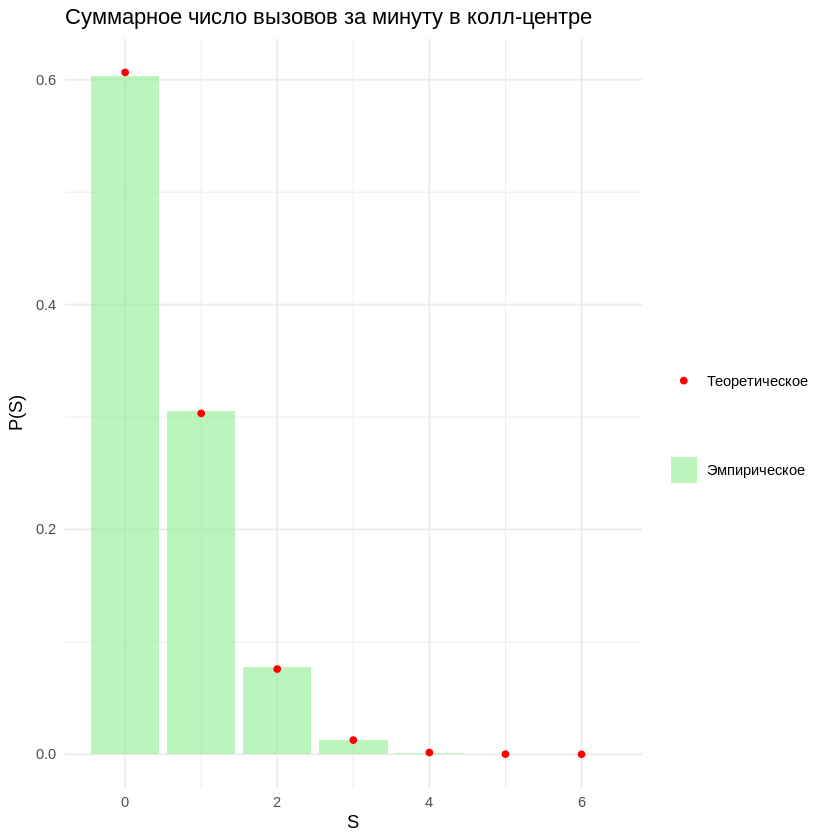

In [5]:
lambda1 <- 0.1
lambda2 <- 0.25
lambda3 <- 0.15
lambda_tot <- lambda1 + lambda2 + lambda3

# Теоретическое распределение: сумма независимых пуассоновских потоков – тоже Пуассон
# S ~ Pois(lambda_tot)

cat("Суммарный параметр потока (звонков в минуту): λ_tot =", lambda_tot, "\n")

# Вероятность не более 2 вызовов за минуту
P_le_2 <- ppois(2, lambda_tot)
cat("P(S <= 2):", P_le_2, "\n")

# M[S], D[S], σ, коэффициент вариации
ES <- lambda_tot
DS <- lambda_tot
SD_S <- sqrt(DS)
CV_S <- SD_S / ES

cat("M[S]:", ES, "\n")
cat("D[S]:", DS, "\n")
cat("σ[S]:", SD_S, "\n")
cat("Коэффициент вариации k_v:", CV_S, "\n\n")

# Имитационная модель (по числу вызовов за минуту)
set.seed(2026 + 10 + 4)
N <- 100000
X1 <- rpois(N, lambda1)
X2 <- rpois(N, lambda2)
X3 <- rpois(N, lambda3)
S <- X1 + X2 + X3

cat("Выборочное M[S]:", mean(S), "\n")
cat("Выборочная D[S]:", var(S), "\n")
cat("Оценка P(S <= 2) по моделированию:", mean(S <= 2), "\n\n")

# Сравнение теоретического и эмпирического распределения
k_vals <- 0:max(S)
p_theor <- dpois(k_vals, lambda_tot)
tab_emp <- table(factor(S, levels = k_vals)) / N
p_emp <- as.numeric(tab_emp)

df_theor <- data.frame(k = k_vals, P = p_theor)
df_emp <- data.frame(k = k_vals, P = p_emp)

ggplot() +
  geom_col(data = df_emp, aes(x = k, y = P, fill = "Эмпирическое"), alpha = 0.6) +
  geom_point(data = df_theor, aes(x = k, y = P, colour = "Теоретическое"), size = 1.5) +
  labs(title = "Суммарное число вызовов за минуту в колл-центре",
       x = "S", y = "P(S)") +
  scale_fill_manual(values = c("Эмпирическое" = "lightgreen"), name = "") +
  scale_colour_manual(values = c("Теоретическое" = "red"), name = "") +
  theme_minimal()

## Заключение

- **Раздел 1, задание 6**: оценены интенсивности отказов в нормальных и тяжелых условиях, проверены экспоненциальные модели и выполнен односторонний t‑тест, даны оценки параметров возможного Эрланга.
- **Раздел 2, задача 5**: получено распределение числа обработанных заявок $Y = \min(S, 10)$, вычислены $M[Y]$, $D[Y]$, вероятность потерь и условное $M[S \mid S>10]$, результаты проверены моделированием.
- **Раздел 3, задание 4**: для суммарного потока вызовов получено пуассоновское распределение, найдены основные характеристики и вероятность $P(S \le 2)$, теоретические результаты подтверждены имитацией.

